In this notebook, we explore the dynamics of the "Smart-Predict then Optimize" paper and its proposed surrogate loss function SPO+. Specifically, we explore its performance relative to the tradtiional predict then optimize paradigm with vanilla mean squared error (MSE) prediction loss. Some simple, intentional examples are constructed, to gain some intuition before moving on to more "blackbox" experiments. 

In [146]:
import pyepo
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

In [182]:
#-------------------------------------------------------------------------------------------------
#Helper Functions
#-------------------------------------------------------------------------------------------------

#Function to take data points and plot scatter plot with optional regression lines
def plot_2d(x, y, xlbl, ylbl, title=None, regression=None):
    plt.scatter(x,y, c='gray')
    if regression is not None:
        x_line = np.array([min(x), max(x)])
        for line in regression: 
            y_line = line['weights'] * x_line + line['bias']
            plt.plot(x_line, y_line, label=line['type'])
        plt.legend()
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)
    plt.title(title)
    plt.show()

#Function to train models and record statistics
def trainModel(loader_train, loader_test, optmodel, model, criterion, name, epochs=25, lr=1e-1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_loss_log, train_regret_log = [], []
    test_loss_log, test_regret_log = [], []
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        temp_loss = []
        for data in loader_train:
            x, c, w, z = data
            cp = model(x)
            
            loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            temp_loss.append(loss.item())

        # Calculate Training Metrics (Once per epoch)
        train_loss_log.append(np.mean(temp_loss))
        train_regret_log.append(pyepo.metric.regret(model, optmodel, loader_train))

        # --- TESTING ---
        model.eval() # Important for consistency
        temp_loss = []
        with torch.no_grad():
            for data in loader_test:
                x, c, w, z = data
                cp = model(x)
                loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
                temp_loss.append(loss.item())
        
        # Calculate Testing Metrics (Once per epoch)
        test_loss_log.append(np.mean(temp_loss))
        test_regret_log.append(pyepo.metric.regret(model, optmodel, loader_test))

        if epoch % 10 == 0:
            print(f'Epoch: {epoch} Loss Type: {name}')
            print(f'Train Loss {train_loss_log[-1]:.2f} Test Loss {test_loss_log[-1]:.2f}')
            print(f'Train Regret {train_regret_log[-1] *100:.2f}% Test Regret {test_regret_log[-1]*100:.2f}%')

    return train_loss_log, test_loss_log, train_regret_log, test_regret_log

#Funtion to plot trajectory of training curves
def plotLearningCurves(train_loss, test_loss, train_regret, test_regret, name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    epochs = range(len(train_loss))

    # --- Plot 1: Loss (Prediction Error) ---
    ax[0].plot(epochs, train_loss, label='Train Loss', color='blue', lw=2)
    ax[0].plot(epochs, test_loss, label='Test Loss', color='lightblue', linestyle='--')
    ax[0].set_title(f'{name} Loss Trajectory')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- Plot 2: Regret (Decision Error) ---
    ax[1].plot(epochs, [r * 100 for r in train_regret], label='Train Regret', color='green', lw=2)
    ax[1].plot(epochs, [r * 100 for r in test_regret], label='Test Regret', color='lightgreen', linestyle='--')
    ax[1].set_title(f'{name} Regret Trajectory')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Regret (%)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#-------------------------------------------------------------------------------------------------
#Models
#-------------------------------------------------------------------------------------------------

#Linear Regression Model
class LinearRegression(nn.Module):
    def __init__(self, num_feat, num_item):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(num_feat, num_item)

    def forward(self, x):
        out = self.linear(x)
        return out

#MLP Model
class MLP(nn.Module):
    def __init__(self, num_feat, hidden, num_item):
        super(MLP, self).__init__()
        self.l1 = nn.Linear(num_feat, hidden)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden, num_item)
        
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out
#Knapsack
class Knapsack():
    def __init__(self, weights, capacity):
        self.num_items = len(weights)
        self.model = gp.Model("knapsack")
        self.model.setParam('OutputFlag', 0)  # Silence Gurobi output
        # Decision variables: x[i] is 1 if item i is selected, 0 otherwise
        self.x = self.model.addVars(self.num_items, vtype=GRB.BINARY, name="x")

        # Constraint: Total weight <= Capacity
        self.model.addConstr(sum(weights[i] * self.x[i] for i in range(self.num_items)) <= capacity, "Capacity")

    def set_objective(self, values):
        self.model.setObjective(sum(values[i] * self.x[i] for i in range(self.num_items)), GRB.MAXIMIZE)
    
    def solve(self):
        self.model.optimize()
        # Extract solution
        if self.model.status == GRB.OPTIMAL:
            selected = [i for i in range(self.num_items) if self.x[i].x > 0.5]
            return selected, self.model.objVal
        else:
            return None

In [183]:
#Simple Example
#Generate Random Features (num_feat, num_samples)
features = 10 * torch.rand((1,1000))
#Mapping (num_item, num_feat)
item_map = torch.tensor([3, 7, 9.5], dtype=torch.float32).unsqueeze(1)

#Generate Values from item mapping (num_item, num_samples)
values = item_map @ features
#Add Noise to the values
#values += torch.randn_like(values)
#Shift Values so none are at zero
values -= torch.min(values, dim=1, keepdim=True).values

#Add Outliers
values[2] = torch.where(values[2] > 90, values[2] + 100, values[2])

#Generate Weights (num_item)
weights = torch.tensor([3, 7, 8])

#Set capacity of knapsack
capacity = 10

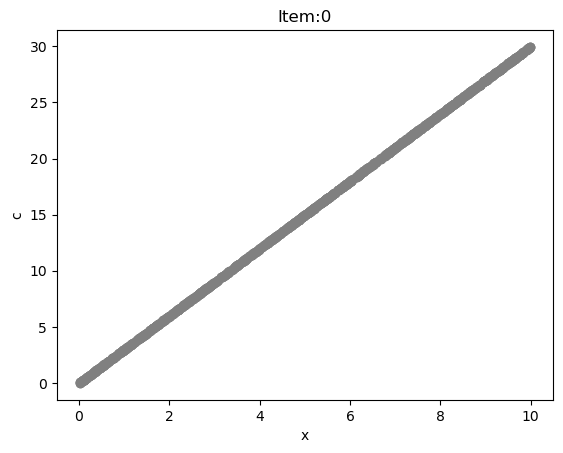

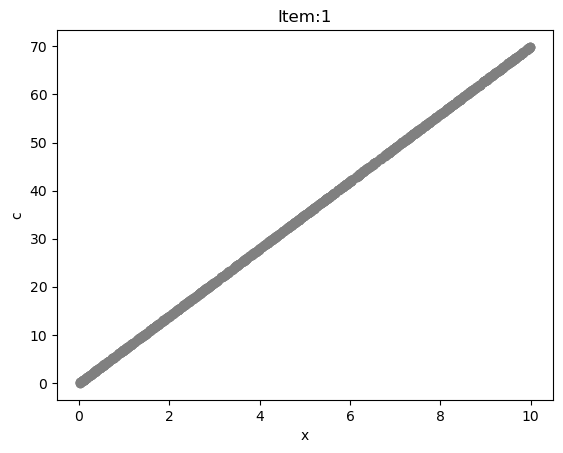

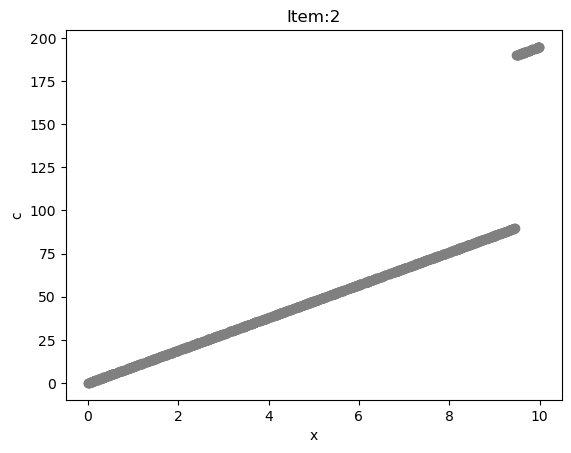

In [184]:
#Visualize the items
for item in range(len(weights)):
    plot_2d(features[0], values[item,], 'x', 'c', f'Item:{item}')

In [185]:
#Partition Data
#Split Data Into Train / Test
feat_train, feat_test, value_train, value_test = train_test_split(features.T, values.T, test_size= int(features.shape[1] *.9))

#Create Optimization Model Datasets, and Data Loaders
optmodel = pyepo.model.grb.knapsackModel(weights.view(1, -1), capacity)
dataset_train = pyepo.data.dataset.optDataset(optmodel, feat_train, value_train)
dataset_test = pyepo.data.dataset.optDataset(optmodel, feat_test, value_test)

batch_size = 100
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

Optimizing for optDataset...


100%|██████████| 100/100 [00:00<00:00, 2391.88it/s]

Optimizing for optDataset...



100%|██████████| 900/900 [00:00<00:00, 2715.25it/s]


Epoch: 0 Loss Type: MSE
Train Loss 2187.97 Test Loss 2241.85
Train Regret 63.47% Test Regret 59.95%
Epoch: 10 Loss Type: MSE
Train Loss 1717.17 Test Loss 1734.30
Train Regret 11.17% Test Regret 8.79%
Epoch: 20 Loss Type: MSE
Train Loss 1335.98 Test Loss 1327.21
Train Regret 11.17% Test Regret 8.79%
Epoch: 30 Loss Type: MSE
Train Loss 1040.57 Test Loss 1014.67
Train Regret 11.17% Test Regret 8.79%
Epoch: 40 Loss Type: MSE
Train Loss 816.02 Test Loss 779.17
Train Regret 11.17% Test Regret 8.79%
Epoch: 50 Loss Type: MSE
Train Loss 645.74 Test Loss 602.39
Train Regret 11.17% Test Regret 8.79%
Epoch: 60 Loss Type: MSE
Train Loss 517.75 Test Loss 471.34
Train Regret 11.17% Test Regret 8.79%
Epoch: 70 Loss Type: MSE
Train Loss 423.28 Test Loss 376.30
Train Regret 11.17% Test Regret 8.79%
Epoch: 80 Loss Type: MSE
Train Loss 354.55 Test Loss 308.58
Train Regret 11.17% Test Regret 8.79%
Epoch: 90 Loss Type: MSE
Train Loss 304.88 Test Loss 260.89
Train Regret 11.17% Test Regret 8.79%
Epoch: 100 L

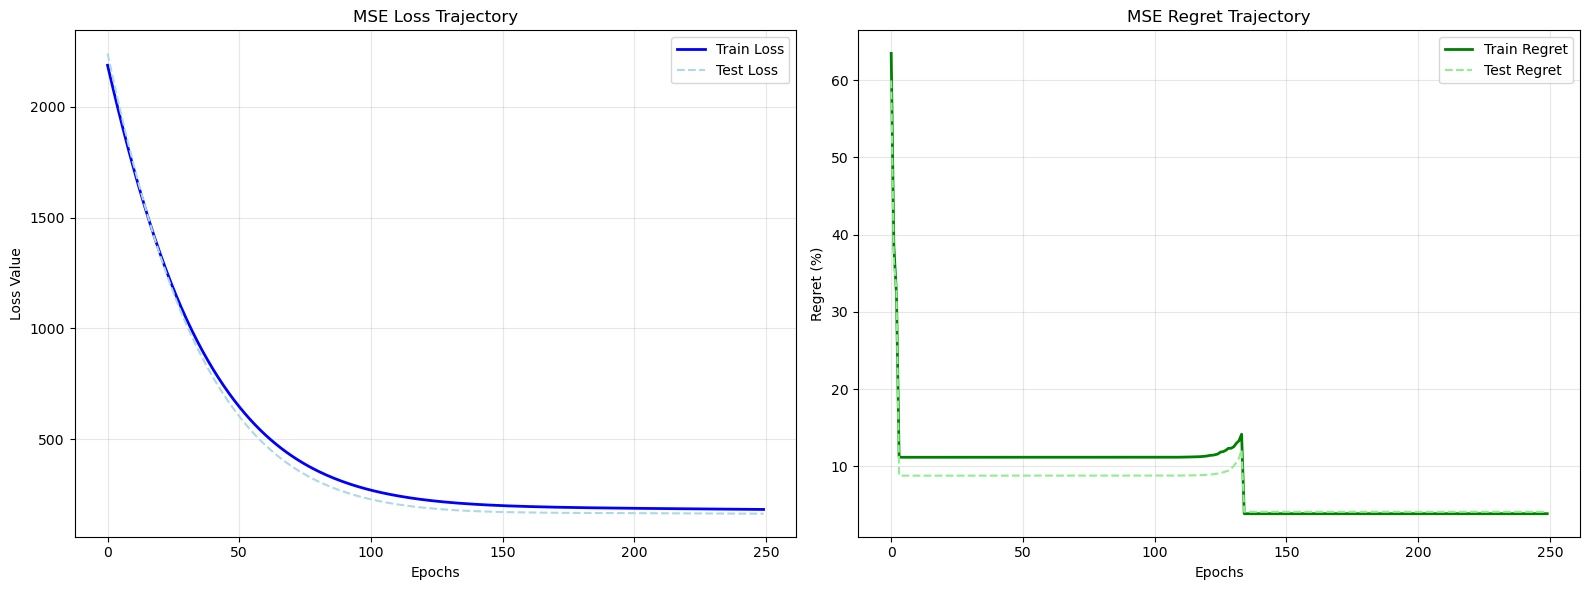

In [191]:
#Train simple Linear Regression with mean squared error
model_mse = LinearRegression(features.shape[0], values.shape[0])
mse = nn.MSELoss()
logs_mse = trainModel(loader_train, loader_test, optmodel, model_mse, mse, "MSE", epochs=250)
plotLearningCurves(*logs_mse, name="MSE")

In [ ]:
#Train simple Linear Regression with spo+
model_spo = LinearRegression(features.shape[0], values.shape[0])
spo = pyepo.func.SPOPlus(optmodel, processes=1)
logs_spo = trainModel(loader_train, loader_test, optmodel, model_spo, spo, "SPO+", epochs=100)
plotLearningCurves(*logs_spo, name="SPO+")

Num of cores: 1
Epoch: 0 Loss Type: SPO+
Train Loss 59.50 Test Loss 41.71
Train Regret 11.17% Test Regret 8.79%
Epoch: 10 Loss Type: SPO+
Train Loss 7.19 Test Loss 5.19
Train Regret 11.17% Test Regret 8.79%
Epoch: 20 Loss Type: SPO+
Train Loss 9.11 Test Loss 7.51
Train Regret 11.17% Test Regret 8.79%
Epoch: 30 Loss Type: SPO+
Train Loss 6.48 Test Loss 5.70
Train Regret 11.17% Test Regret 8.79%
Epoch: 40 Loss Type: SPO+
Train Loss 6.22 Test Loss 5.13
Train Regret 11.17% Test Regret 8.79%


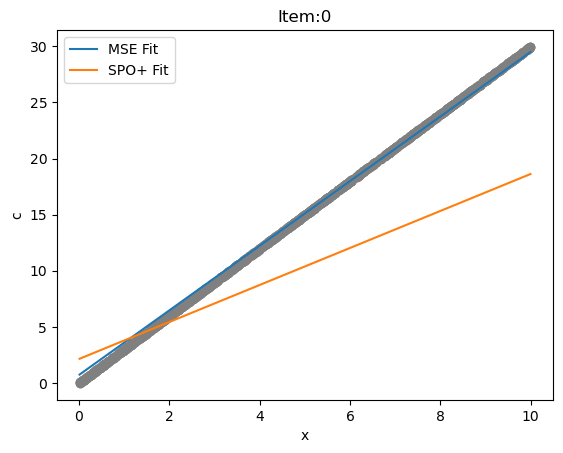

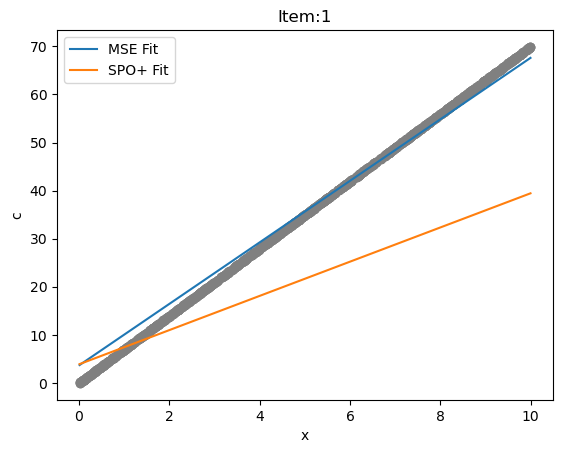

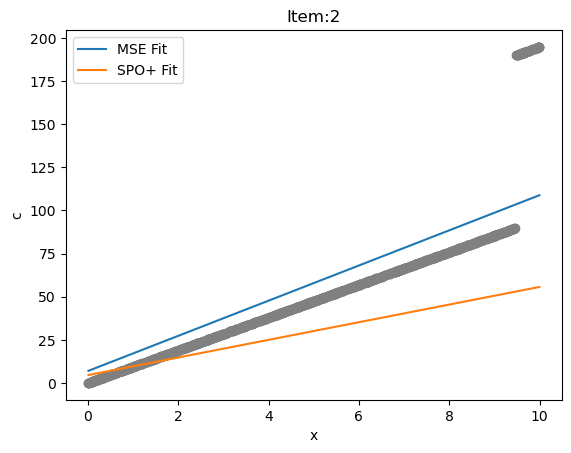

In [192]:
for item in range(len(weights)):
    fits = [
    {'type' : 'MSE Fit', 'weights' : model_mse.linear.weight.detach()[item], 'bias' : model_mse.linear.bias.detach()[item]},
    {'type' : 'SPO+ Fit', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]},
    ]
    plot_2d(features[0], values[item,], 'x', 'c', f'Item:{item}', fits)

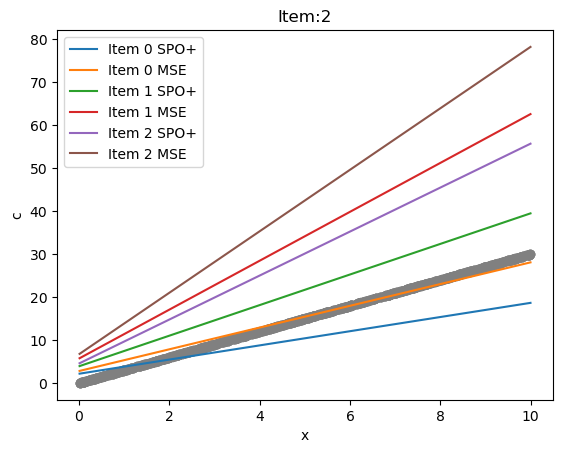

In [189]:
fits = []
for item in range(len(weights)):
    fits.append({'type' : f'Item {item} SPO+', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]})
    fits.append({'type' : f'Item {item} MSE', 'weights' : model_mse.linear.weight.detach()[item], 'bias' : model_mse.linear.bias.detach()[item]})
    
plot_2d(features[0], values[0,], 'x', 'c', f'Item:{item}', fits)

In [190]:
problem = Knapsack(weights, capacity)
start = int(torch.min(features).item())
stop = int(torch.max(features).item())
print("-" * 60)
print(f"{'Feature (x)'} | {'True Opt Item'} | {'MSE Pred Item'} |{'SPO+ Pred Item'}")
print("-" * 60)
for x in np.linspace(start, stop, num = 50):
    optimal = item_map * x
    mse = model_mse(torch.tensor(x, dtype=torch.float32).unsqueeze(0)).tolist()
    spo = model_spo(torch.tensor(x, dtype=torch.float32).unsqueeze(0)).tolist()
    
    problem.set_objective(optimal)
    optimal_solution, optimal_objective = problem.solve()

    problem.set_objective(mse)
    mse_solution, mse_objective = problem.solve()

    problem.set_objective(spo)
    spo_solution, spo_objective = problem.solve()
    print(f"{x:2f} | {str(optimal_solution)} | {str(mse_solution)} | {str(spo_solution)}")
    

------------------------------------------------------------
Feature (x) | True Opt Item | MSE Pred Item |SPO+ Pred Item
------------------------------------------------------------
0.000000 | [] | [0, 1] | [0, 1]
0.183673 | [0, 1] | [0, 1] | [0, 1]
0.367347 | [0, 1] | [0, 1] | [0, 1]
0.551020 | [0, 1] | [0, 1] | [0, 1]
0.734694 | [0, 1] | [0, 1] | [0, 1]
0.918367 | [0, 1] | [0, 1] | [0, 1]
1.102041 | [0, 1] | [0, 1] | [0, 1]
1.285714 | [0, 1] | [0, 1] | [0, 1]
1.469388 | [0, 1] | [0, 1] | [0, 1]
1.653061 | [0, 1] | [0, 1] | [0, 1]
1.836735 | [0, 1] | [0, 1] | [0, 1]
2.020408 | [0, 1] | [0, 1] | [0, 1]
2.204082 | [0, 1] | [0, 1] | [0, 1]
2.387755 | [0, 1] | [0, 1] | [0, 1]
2.571429 | [0, 1] | [0, 1] | [0, 1]
2.755102 | [0, 1] | [0, 1] | [0, 1]
2.938776 | [0, 1] | [0, 1] | [0, 1]
3.122449 | [0, 1] | [0, 1] | [0, 1]
3.306122 | [0, 1] | [0, 1] | [0, 1]
3.489796 | [0, 1] | [0, 1] | [0, 1]
3.673469 | [0, 1] | [0, 1] | [0, 1]
3.857143 | [0, 1] | [0, 1] | [0, 1]
4.040816 | [0, 1] | [0, 1] | [

In [9]:
#Parameters
i = 10 #items
n = 1000 #samples of data
d = 1 #numper of features
p = 1 #power of polynomial cost function
ec = 1 #noise multiplier for generating costs
ew = 5 #noise multiplied for generating weights
capPCT = 0.4 #capacity of knapsack as a % of total weight

#Generate Random Features
x = 10 * torch.rand((d,n))
#Generate Random Mapping
A = torch.randn((i,d))
#Generate Costs
c = (A @ x) ** p 
#Add Noise to Costs
c += ec * (torch.mean(c, dim=1, keepdim=True) * torch.rand(i,1) * torch.randn_like(c))
#Shift Values to have minimum at zero
c -= torch.min(c, dim=1, keepdim=True).values
#Generate Weights
w = torch.mean(c, dim=1) + (ew * torch.std(c, dim=1) * torch.randn(i))
w -= torch.min(w) - 1
#Calculate capacity
capacity = [int(torch.sum(w) * capPCT)]
print(w.shape)

torch.Size([10])


In [6]:
print(f'Avg. Stdev. of Cost to Weight: {torch.mean(torch.std(c / w.unsqueeze(1), dim=0)):.2f}')

Avg. Stdev. of Cost to Weight: 2.14


C:\Users\Loper Laptop\AppData\Local\Temp\ipykernel_31764\154592895.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


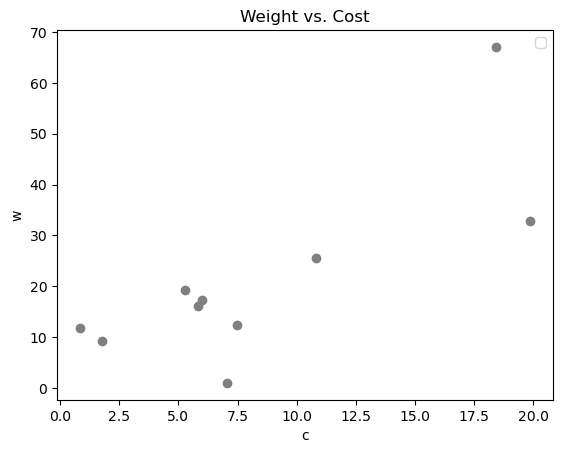

In [ ]:
plot_2d(torch.mean(c, dim=1), w, 'c', 'w', 'Weight vs. Cost')

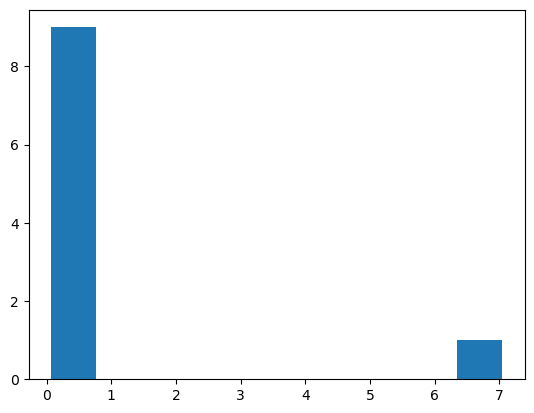

In [9]:
plt.hist(torch.mean(c, dim=1) / w)
plt.show()

In [17]:
labels = [f'Item {i}' for i in range(len(w))]
df = pd.DataFrame({
    "Items" : labels,
    "Weights" : w.tolist(),
    "Avg. Value" : torch.mean(c, dim = 1).tolist(),
    "Avg. Ratio" : (torch.mean(c, dim = 1) / w).tolist()
})
print(df.sort_values(by='Avg. Ratio', ascending=False))

    Items    Weights  Avg. Value  Avg. Ratio
3  Item 3   1.000000    7.043869    7.043869
1  Item 1  32.785988   19.891579    0.606710
0  Item 0  12.423903    7.455101    0.600061
5  Item 5  25.583294   10.821568    0.422994
8  Item 8  16.057194    5.833609    0.363302
9  Item 9  17.335583    6.003517    0.346312
6  Item 6  67.068474   18.437796    0.274910
7  Item 7  19.344952    5.288748    0.273392
4  Item 4   9.202078    1.752771    0.190476
2  Item 2  11.770218    0.816261    0.069350


In [145]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from sklearn.linear_model import LinearRegression

def solve_knapsack(values, weights, capacity):
    """
    Solves the knapsack problem using Gurobi.
    Returns: chosen_items (list of indices), objective_value
    """
    num_items = len(values)
    m = gp.Model("knapsack")
    m.setParam('OutputFlag', 0)  # Silence Gurobi output

    # Decision variables: x[i] is 1 if item i is selected, 0 otherwise
    x = m.addVars(num_items, vtype=GRB.BINARY, name="x")

    # Objective: Maximize total value
    m.setObjective(sum(values[i] * x[i] for i in range(num_items)), GRB.MAXIMIZE)

    # Constraint: Total weight <= Capacity
    m.addConstr(sum(weights[i] * x[i] for i in range(num_items)) <= capacity, "Capacity")

    m.optimize()

    # Extract solution
    if m.status == GRB.OPTIMAL:
        selected = [i for i in range(num_items) if x[i].x > 0.5]
        return selected, m.objVal
    else:
        return [], 0

# --- 1. Generate Synthetic Data ---
np.random.seed(42)
n_samples = 100
# Features: Simple range from 0 to 10
X = np.linspace(0, 10, n_samples).reshape(-1, 1)

# True slopes (The "Hidden" Truth)
# Item 0+1 = 10x value (Weight 3+7=10)
# Item 2   = 9.5x value (Weight 8) -> Strictly worse than 0+1, but close!
true_slopes = np.array([3, 7, 9.5]) 
Y_true = X @ true_slopes.reshape(1, -1)

# Add Massive Outliers to Item 2 (The "Trap")
# For the top 5% of data (x > 9.5), we add a huge spike to Item 2
Y_noisy = Y_true.copy()
outlier_mask = (X > 9.0).flatten()
# Add +50 to Item 2 in the outlier region. 
# This pulls the regression line UP significantly.
Y_noisy[outlier_mask, 2] += 50 

weights = [3, 7, 8]
capacity = 10

# --- 2. Train MSE Model ---
# We fit a standard linear regression to the noisy data
model = LinearRegression()
model.fit(X, Y_noisy)

print(f"True Slopes: {true_slopes}")
print(f"MSE Learned Slopes: {model.coef_.flatten().round(2)}")
print("-" * 60)
print(f"{'Feature (x)':<12} | {'True Opt Item':<15} | {'MSE Pred Item':<15} | {'Result'}")
print("-" * 60)

# --- 3. Loop and Solve ---
# We iterate through a few test points to see the decisions
test_features = [1.0, 3.0, 5.0, 8.0] # Normal range
test_features.append(9.5)            # The outlier range

for x_val in test_features:
    # 1. Get True Costs (Ground Truth)
    c_true = true_slopes * x_val
    
    # 2. Get Predicted Costs (What MSE thinks)
    # Reshape because sklearn expects 2D array
    c_pred = model.predict([[x_val]])[0] 
    
    # 3. Solve True Model (Oracle)
    sol_true, obj_true = solve_knapsack(c_true, weights, capacity)
    
    # 4. Solve Predicted Model (MSE Decision)
    sol_pred, obj_pred = solve_knapsack(c_pred, weights, capacity)
    
    # Calculate the True Value of the Predicted Decision (Regret calculation)
    # If we picked sol_pred, how much True Value did we actually get?
    actual_value_of_pred = sum([c_true[i] for i in sol_pred])
    
    is_correct = (set(sol_true) == set(sol_pred))
    status = "✅ OK" if is_correct else "❌ FAIL"
    
    print(f"{x_val:<12} | {str(sol_true):<15} | {str(sol_pred):<15} | {status}")
    
    if not is_correct:
         regret = obj_true - actual_value_of_pred
         print(f"   >>> MSE thought Item 2 was {c_pred[2]:.2f}, but it is really {c_true[2]:.2f}")
         print(f"   >>> Regret: Lost {regret:.2f} value by picking wrong items.")

True Slopes: [3.  7.  9.5]
MSE Learned Slopes: [ 3.    7.   12.17]
------------------------------------------------------------
Feature (x)  | True Opt Item   | MSE Pred Item   | Result
------------------------------------------------------------
1.0          | [0, 1]          | [0, 1]          | ✅ OK
3.0          | [0, 1]          | [0, 1]          | ✅ OK
5.0          | [0, 1]          | [2]             | ❌ FAIL
   >>> MSE thought Item 2 was 52.50, but it is really 47.50
   >>> Regret: Lost 2.50 value by picking wrong items.
8.0          | [0, 1]          | [2]             | ❌ FAIL
   >>> MSE thought Item 2 was 89.02, but it is really 76.00
   >>> Regret: Lost 4.00 value by picking wrong items.
9.5          | [0, 1]          | [2]             | ❌ FAIL
   >>> MSE thought Item 2 was 107.28, but it is really 90.25
   >>> Regret: Lost 4.75 value by picking wrong items.
